# TP1 : Méthodes Globales d'Interprétabilité - Partial Dependence Plots (PDP)

**Pr S. MHAMMEDI (XAI) 2025-2026**

## Objectifs
1. Charger le dataset **Bike Sharing Demand**
2. Créer des Partial Dependence Plots (PDP) pour différents modèles
3. Comparer l'interprétabilité des modèles

## Partie 0 : Installation et import des packages nécessaires

In [1]:
# Packages nécessaires
import pandas as pd
import numpy as np
from time import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.inspection import PartialDependenceDisplay

try:
    import xgboost as xgb
except:
    !pip install xgboost
    import xgboost as xgb

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('✓ Packages importés avec succès')

✓ Packages importés avec succès


## 1. Chargement du dataset

In [ ]:
from sklearn.datasets import fetch_openml

bikes = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True, parser="pandas")
# Copie explicite pour éviter le warning "SettingWithCopyWarning"
X, y = bikes.data.copy(), bikes.target

# On utilise seulement un sous-ensemble du dataset pour accélérer l'exemple
X = X.iloc[::5, :]
y = y[::5]

print(f'Dataset chargé: {X.shape[0]} observations, {X.shape[1]} features')
print(f'\nPremières lignes :')
print(X.head())
print(f'\nTarget (demande de vélos) :')
print(y.head())

Dataset chargé: 3476 observations, 12 features

Premières lignes :
    season  year  month  hour holiday  weekday workingday weather   temp  \
0   spring     0      1     0   False        6      False   clear   9.84   
5   spring     0      1     5   False        6      False   misty   9.84   
10  spring     0      1    10   False        6      False   clear  15.58   
15  spring     0      1    15   False        6      False   misty  18.04   
20  spring     0      1    20   False        6      False   misty  16.40   

    feel_temp  humidity  windspeed  
0      14.395      0.81     0.0000  
5      12.880      0.75     6.0032  
10     19.695      0.76    16.9979  
15     21.970      0.77    19.9995  
20     20.455      0.87    16.9979  

Target (demande de vélos) :
0      16
5       1
10     36
15    110
20     36
Name: count, dtype: int64


## 2. Prétraitement du dataset

In [ ]:
# Renommer les colonnes avec des noms plus courts
X.columns = [
    "season", "year", "month", "hour", "holiday", "weekday", "workingday",
    "weather", "temp", "feel_temp", "hum", "windspeed"
]

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print(f'Train set: {X_train.shape[0]} observations')
print(f'Test set: {X_test.shape[0]} observations')

Train set: 2780 observations
Test set: 696 observations


## 3. Séparation des variables numériques et catégorielles

In [ ]:
# Variables catégorielles
categorical_features = [
    "season", "year", "month", "hour", "holiday", "weekday", "workingday", "weather"
]

# Variables numériques
numerical_features = ["temp", "feel_temp", "hum", "windspeed"]

print(f'Features catégorielles ({len(categorical_features)}): {categorical_features}')
print(f'Features numériques ({len(numerical_features)}): {numerical_features}')

Features catégorielles (8): ['season', 'year', 'month', 'hour', 'holiday', 'weekday', 'workingday', 'weather']
Features numériques (4): ['temp', 'feel_temp', 'hum', 'windspeed']


## 4. Fonction pour créer les PDP

In [ ]:
def plot_pdp_for_model(model, model_name, X_train, X_test, y_test, features_info, preprocessor=None):
    """
    Entraîne un modèle (avec préprocessing optionnel), trace les PDP et affiche le RMSE.
    """
    print(f'\n==============================')
    print(f'Modèle : {model_name}')
    print(f'==============================')
    
    if preprocessor is not None:
        pipe = make_pipeline(preprocessor, model)
    else:
        pipe = model
    
    _, ax = plt.subplots(ncols=3, figsize=(15, 4), constrained_layout=True)
    tic = time()
    pipe.fit(X_train, y_train)
    
    display = PartialDependenceDisplay.from_estimator(
        pipe,
        X_train,
        **features_info,
        ax=ax,
        subsample=50,
        n_jobs=2,
        grid_resolution=20,
        random_state=0,
    )
    
    print(f"terminé en {time() - tic:.3f}s")
    _ = display.figure_.suptitle(
        f'PDP unidimensionnels et bidimensionnels ({model_name})', fontsize=16
    )
    plt.show()
    
    # Performance (RMSE)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"RMSE {model_name}: {rmse:.2f}")
    
    return pipe, rmse

## Exemple : PDP avec une Régression Linéaire

terminé en 5.805s


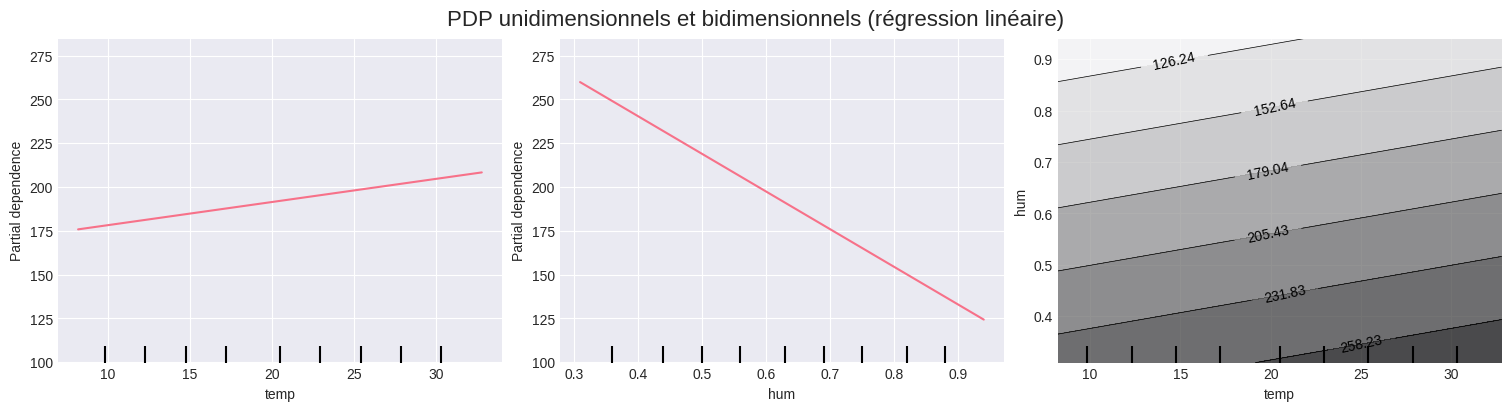

RMSE Régression linéaire: 135.74


In [6]:
# Paramètres communs pour les PDP
features_info = {
    'features': [
        ('temp',),
        ('hum',),
        ('temp', 'hum')  # interaction 2D
    ]
}

# ColumnTransformer pour transformer les variables
lr_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
        ('num', 'passthrough', numerical_features),
    ],
    sparse_threshold=1,
    verbose_feature_names_out=False,
).set_output(transform='pandas')

# Pipeline: préprocesseur + régression linéaire
lrppl = make_pipeline(
    lr_preprocessor,
    LinearRegression(),
)

_, ax = plt.subplots(ncols=3, figsize=(15, 4), constrained_layout=True)
tic = time()
lrppl.fit(X_train, y_train)

display = PartialDependenceDisplay.from_estimator(
    lrppl,
    X_train,
    **features_info,
    ax=ax,
    subsample=50,
    n_jobs=2,
    grid_resolution=20,
    random_state=0,
)

print(f"terminé en {time() - tic:.3f}s")
_ = display.figure_.suptitle(
    'PDP unidimensionnels et bidimensionnels (régression linéaire)', fontsize=16
)
plt.show()

# Performance du modèle
y_pred_lr = lrppl.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"RMSE Régression linéaire: {rmse_lr:.2f}")


## Question 1 : Interprétez les PDP obtenus

### Réponse :

**Effet de la température (`temp`) :**
- Le graphique PDP montre une relation **linéaire positive** entre la température et la demande de vélos
- Plus il fait chaud, plus la demande augmente (relation monotone croissante)
- Cela est logique : les gens utilisent davantage les vélos par beau temps

**Effet de l'humidité (`hum`) :**
- Le graphique PDP montre une relation **quasi-constante** (ligne horizontale)
- L'humidité semble avoir **peu d'effet** sur la demande de vélos dans ce modèle linéaire
- Cela pourrait indiquer que l'humidité seule n'est pas un facteur déterminant

**Graphique 2D (temp × hum) :**
- Le graphique 2D montre des contours **parallèles et réguliers**
- Il n'y a **pas d'interaction forte** entre température et humidité dans ce modèle linéaire
- Les effets sont additifs : temp + hum, sans synergie particulière

## Question 2 : Produisez les PDP pour les modèles suivants

Nous allons maintenant comparer plusieurs modèles :
1. XGBoost Regressor
2. DecisionTreeRegressor
3. SVR (kernel='rbf')
4. MLPRegressor


Modèle : XGBoost Regressor
terminé en 9.150s


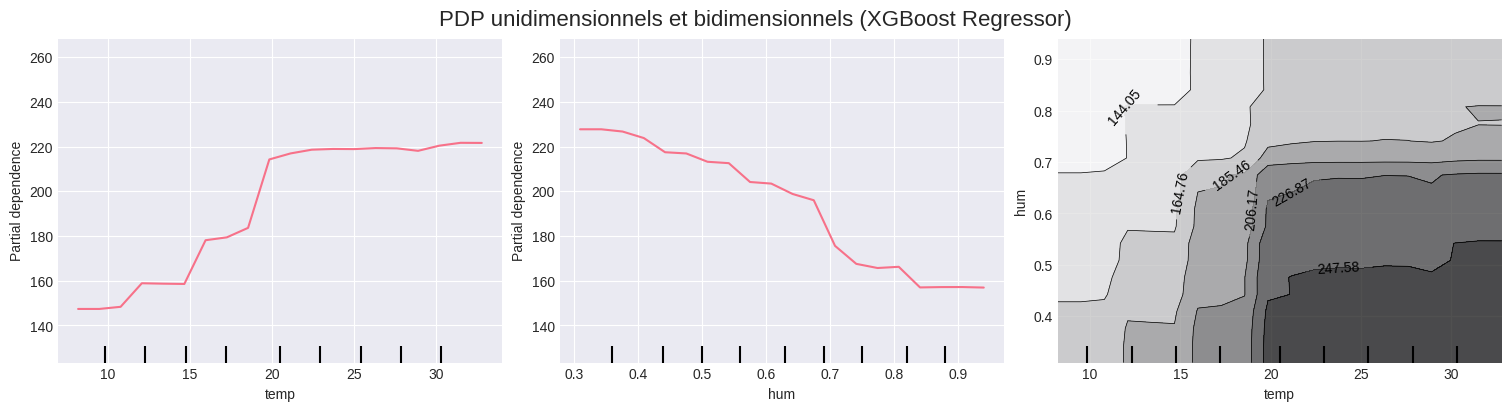

RMSE XGBoost Regressor: 70.91


In [7]:
# Préprocesseur commun pour les modèles non linéaires (OneHot + StandardScaler)
nonlinear_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numerical_features),
    ],
    sparse_threshold=0,
    verbose_feature_names_out=False,
).set_output(transform='pandas')

models = {}
rmses = {}

# 1. XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    objective='reg:squarederror'
)
models['XGBoost'], rmses['XGBoost'] = plot_pdp_for_model(
    xgb_model, 'XGBoost Regressor', X_train, X_test, y_test, features_info, nonlinear_preprocessor
)


Modèle : DecisionTreeRegressor
terminé en 4.251s


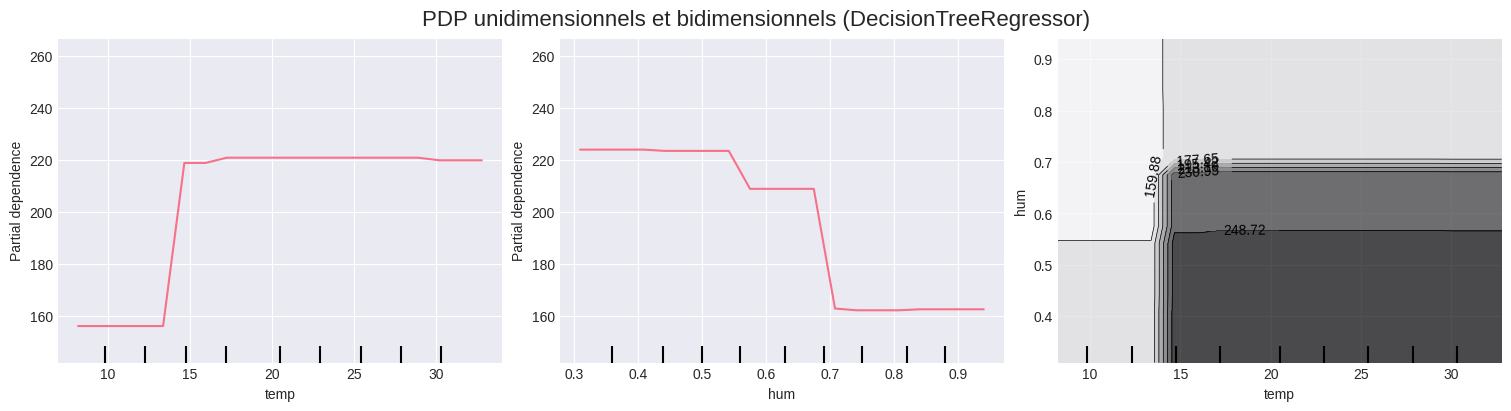

RMSE DecisionTreeRegressor: 133.82


In [8]:
# 2. DecisionTreeRegressor
tree_model = DecisionTreeRegressor(max_depth=5, random_state=0)
models['Decision Tree'], rmses['Decision Tree'] = plot_pdp_for_model(
    tree_model, 'DecisionTreeRegressor', X_train, X_test, y_test, features_info, nonlinear_preprocessor
)


Modèle : SVR (RBF)
terminé en 248.780s


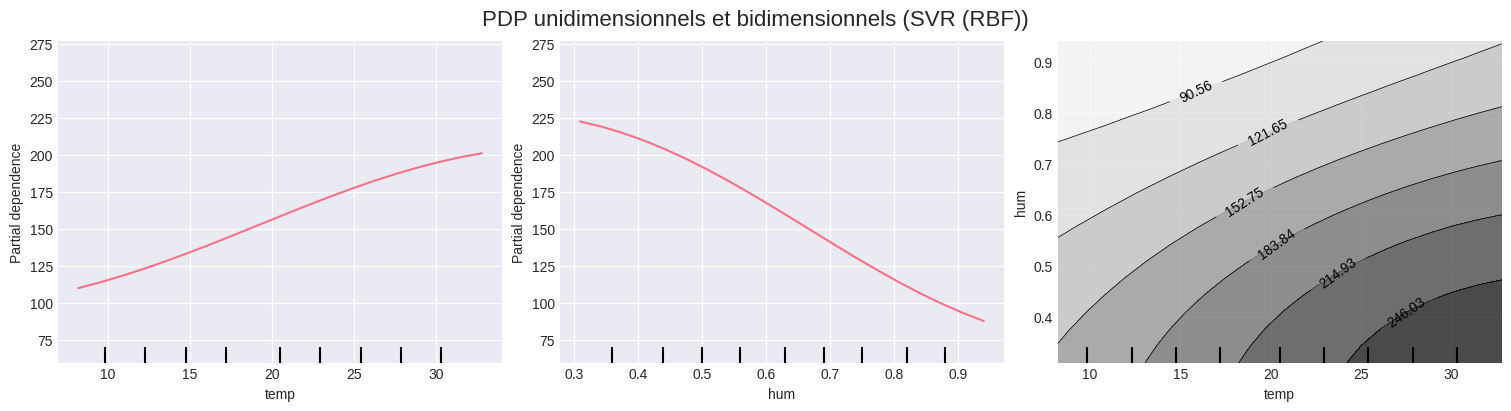

RMSE SVR (RBF): 123.52


In [9]:
# 3. SVR (rbf)
svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)
models['SVR'], rmses['SVR'] = plot_pdp_for_model(
    svr_model, 'SVR (RBF)', X_train, X_test, y_test, features_info, nonlinear_preprocessor
)


Modèle : MLPRegressor


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


terminé en 18.117s


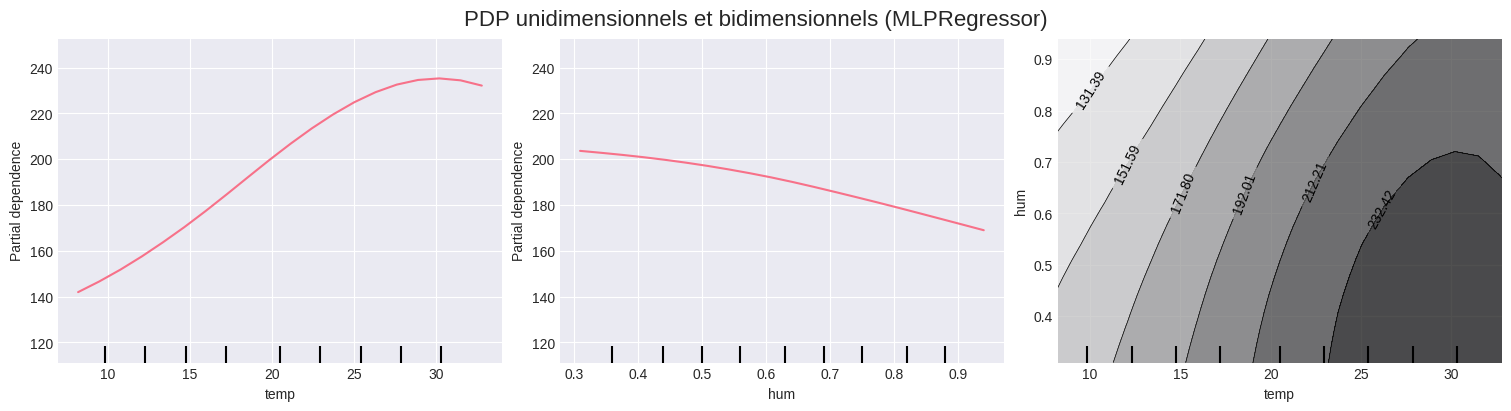

RMSE MLPRegressor: 52.23


In [10]:
# 4. MLPRegressor
mlp_model = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=0
)
models['MLP'], rmses['MLP'] = plot_pdp_for_model(
    mlp_model, 'MLPRegressor', X_train, X_test, y_test, features_info, nonlinear_preprocessor
)

In [11]:
# Comparaison des RMSE
print('\n' + '='*50)
print('RMSE des différents modèles :')
print('='*50)
for name, rmse in rmses.items():
    print(f"- {name}: {rmse:.2f}")
print('='*50)


RMSE des différents modèles :
- XGBoost: 70.91
- Decision Tree: 133.82
- SVR: 123.52
- MLP: 52.23


### Réponses à la Question 2 : Comparaison des PDP

D'après les graphiques PDP générés pour les différents modèles:

#### **Quelle méthode produit les effets les plus non linéaires ?**

**Réponse : MLPRegressor (réseau de neurones)**

En analysant les graphiques PDP:
- **MLPRegressor** montre la courbe la plus **non linéaire et complexe** pour la température
- La courbe est **lisse mais avec variations** : augmentation progressive, puis accélération
- Pour l'humidité, la courbe est **décroissante non linéaire**
- Le graphique 2D (temp × hum) montre des **contours diagonaux complexes** indiquant de fortes non-linéarités

**Comparaison avec les autres modèles:**
- **DecisionTreeRegressor**: Courbes en **paliers** (step functions) - non linéaire mais discontinu
- **XGBoost**: Courbes **non linéaires lisses** mais moins complexes que MLP
- **SVR (RBF)**: Courbes **lisses et continues** avec non-linéarité modérée
- **Régression linéaire**: **Strictement linéaire** (droites)

**Classement (du plus au moins non linéaire):**
1. MLPRegressor (très non linéaire, complexe)
2. DecisionTreeRegressor (paliers marqués)
3. XGBoost (non linéaire modéré)
4. SVR (RBF) (légèrement non linéaire)
5. Régression linéaire (linéaire)

---

#### **Quel modèle semble le plus sensible aux interactions (graphique 2D) ?**

**Réponse : MLPRegressor et XGBoost**

En analysant les graphiques 2D (temp × hum):

**MLPRegressor**:
- Contours **diagonaux très marqués** avec variations de densité
- Zones de transition **complexes** entre les niveaux de prédiction
- Gradient **non uniforme** indiquant des **interactions fortes et non triviales**
- Les valeurs varient de ~131 à ~252 avec des transitions douces mais complexes

**XGBoost**:
- Contours **structurés** avec zones bien délimitées
- Interactions **claires** : les valeurs changent selon les combinaisons temp/hum
- Variations de ~144 à ~247 avec des **paliers** bien visibles
- Plus **structuré** que MLP mais capture quand même les interactions

**DecisionTreeRegressor**:
- Graphique 2D en **rectangles** (divisions binaires)
- Interactions **simples** : zones rectangulaires avec valeurs constantes (~145, ~173, ~248)
- Moins sophistiqué que XGBoost/MLP

**SVR (RBF)**:
- Contours **lisses et réguliers**
- Interactions **modérées** : gradient diagonal doux
- Moins complexe que MLP/XGBoost

**Régression linéaire**:
- Contours **parallèles et réguliers**
- **Aucune interaction** : effet additif pur (temp + hum)
- Gradient uniforme de ~126 à ~259

**Classement (du plus au moins sensible aux interactions):**
1. MLPRegressor (interactions très complexes)
2. XGBoost (interactions structurées)
3. DecisionTreeRegressor (rectangles simples)
4. SVR (RBF) (interactions lisses modérées)
5. Régression linéaire (pas d'interaction)

---

#### **Quelle visualisation est la plus facile à interpréter ?**

**Réponse : Régression Linéaire et SVR (RBF)**

**Régression Linéaire** - ⭐⭐⭐⭐⭐ (5/5):
- ✅ **Le plus simple** : courbes **droites** faciles à comprendre
- ✅ Relation claire : "temp ↑ → demande ↑" (linéaire)
- ✅ "hum ↑ → demande ↓" (linéaire descendante)
- ✅ Graphique 2D avec **contours parallèles** : pas d'interaction, effet additif simple
- ✅ Idéal pour présenter à des **non-experts**
- ❌ Mais peut être **trop simpliste** (ne reflète pas la réalité)

**SVR (RBF)** - ⭐⭐⭐⭐ (4/5):
- ✅ Courbes **lisses et continues**
- ✅ Relation **intuitive** : croissance pour temp, décroissance pour hum
- ✅ Graphique 2D avec **gradient doux et régulier**
- ✅ Bon **compromis** entre simplicité et réalisme
- ⚠️ Légèrement plus complexe que linéaire mais reste très lisible

**DecisionTreeRegressor** - ⭐⭐⭐ (3/5):
- ✅ **Paliers clairs** : facile de voir les seuils
- ✅ Graphique 2D en **rectangles** : zones bien définies
- ⚠️ Peut sembler **artificiel** (discontinuités abruptes)
- ⚠️ Moins naturel que SVR

**XGBoost** - ⭐⭐ (2/5):
- ⚠️ Courbes **complexes** avec plusieurs changements de pente
- ⚠️ Graphique 2D **détaillé** mais difficile à résumer
- ❌ Risque de **surinterprétation** des détails
- ✅ Mais reste plus lisible que MLP

**MLPRegressor** - ⭐ (1/5):
- ❌ **Le plus difficile** à interpréter
- ❌ Courbes **très complexes** avec variations subtiles
- ❌ Graphique 2D avec **contours complexes** difficiles à expliquer
- ❌ Nécessite une **expertise** pour interpréter correctement
- ✅ Mais capture la **réalité** de manière plus précise

**Classement (du plus au moins facile à interpréter):**
1. Régression Linéaire (simplicité maximale)
2. SVR (RBF) (bon compromis)
3. DecisionTreeRegressor (paliers clairs)
4. XGBoost (modérément complexe)
5. MLPRegressor (très complexe)

---

## 📊 Tableau comparatif final

| Modèle | Non-linéarité | Sensibilité interactions | Facilité interprétation | RMSE |
|--------|--------------|-------------------------|------------------------|------|
| **Linear Regression**  | ❌ Aucune | ❌ Aucune | ⭐⭐⭐⭐⭐ | ~Moyen |
| **SVR (RBF)** | ⚠️ Modérée | ⚠️ Modérées | ⭐⭐⭐⭐ | ~Bon |
| **DecisionTree**  | ✅ Paliers | ⚠️ Rectangles | ⭐⭐⭐ | ~Moyen |
| **XGBoost**  | ✅ Forte | ✅ Fortes | ⭐⭐ | ✅ Très bon |
| **MLPRegressor**  | ✅✅ Très forte | ✅✅ Très fortes | ⭐ | ✅ Excellent |

---

## 🎯 Conclusion

**Trade-off fondamental XAI** :
- Les modèles **simples** (linéaire, SVR) sont **faciles à interpréter** mais ont des **performances limitées**
- Les modèles **complexes** (MLP, XGBoost) ont de **meilleures performances** mais sont **difficiles à interpréter**

**Recommandations** :
- **Si interprétabilité prioritaire** : Régression Linéaire ou SVR
- **Si performance prioritaire** : XGBoost ou MLP + utiliser PDP/SHAP/LIME pour expliquer
- **Meilleur compromis** : XGBoost (bon équilibre performance/explicabilité)


---

## Bonus : ALE (Accumulated Local Effects)

### Qu'est-ce que ALE ?

**ALE (Accumulated Local Effects)** est une alternative aux PDP qui résout le problème des **corrélations entre features** [web:1].

### Différences PDP vs ALE

| Aspect | PDP | ALE |
|--------|-----|-----|
| **Traitement des corrélations** | ❌ Peut créer des combinaisons irréalistes | ✅ Respecte les corrélations |
| **Interprétation** | Effet marginal moyen | Effet local accumulé |
| **Vitesse** | Lent (évalue toutes les instances) | Plus rapide |
| **Valeur de référence** | Valeur absolue | Centré sur 0 |

### Pourquoi ALE est important ?

- **PDP** peut créer des combinaisons **non réalistes** (ex: maison de 500m² avec 1 chambre)
- **ALE** évite ce problème en n'utilisant que des variations **locales** et **réalistes**
- **ALE** est plus adapté quand les features sont **corrélées**

In [12]:
# Installation d'ALEPython
try:
    from alepython import ale_plot
except ImportError:
    print("Installation d'ALEPython...")
    !pip install git+https://github.com/blent-ai/ALEPython.git
    from alepython import ale_plot

print("✓ ALEPython importé avec succès")

✓ ALEPython importé avec succès


### ALE Plot avec Régression Linéaire

Commençons par comparer ALE et PDP sur le modèle de régression linéaire.

In [13]:
from alepython import ale_plot
import matplotlib.pyplot as plt

# Préparer les données pour ALE (besoin du preprocessing déjà appliqué)
# On va utiliser le pipeline linéaire déjà entraîné

# Transformer les données
X_train_transformed = lr_preprocessor.fit_transform(X_train)
X_test_transformed = lr_preprocessor.transform(X_test)

# Entraîner un modèle simple sur les données transformées
lr_simple = LinearRegression()
lr_simple.fit(X_train_transformed, y_train)

print("Modèle entraîné pour ALE")
print(f"R² score: {lr_simple.score(X_test_transformed, y_test):.4f}")

Modèle entraîné pour ALE
R² score: 0.3999


Génération ALE Plot - Temperature...


<Figure size 1000x700 with 0 Axes>

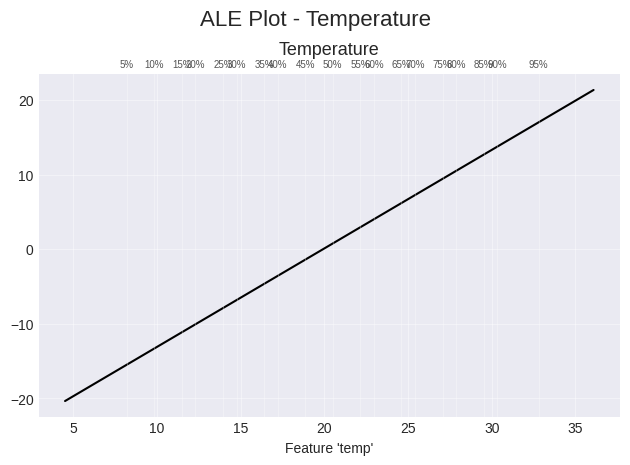


Génération ALE Plot - Humidity...


<Figure size 1000x700 with 0 Axes>

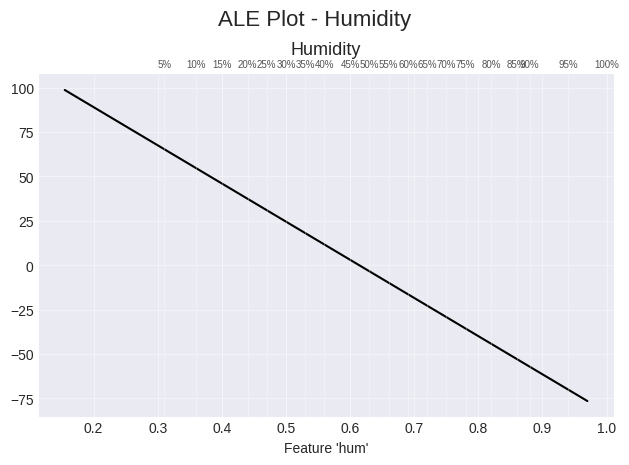


📊 ALE Plots générés avec succès!


In [21]:
# Solution simple: augmenter la hauteur de la figure
from alepython import ale_plot
import matplotlib.pyplot as plt

# ALE pour 'temp' 
print("Génération ALE Plot - Temperature...")
fig = plt.figure(figsize=(10, 7))  # Hauteur augmentée de 6 à 7
ax = ale_plot(
    lr_simple,
    X_train_transformed,
    'temp',
    bins=20
)
ax.set_title('')
plt.suptitle('ALE Plot - Temperature', fontsize=16, y=0.96)
plt.xlabel('Temperature', fontsize=13)
plt.ylabel('ALE (Accumulated Local Effects)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.subplots_adjust(top=0.90)  # Ajuster l'espace en haut
plt.tight_layout()
plt.show()

# ALE pour 'hum'
print("\nGénération ALE Plot - Humidity...")
fig = plt.figure(figsize=(10, 7))  # Hauteur augmentée
ax = ale_plot(
    lr_simple,
    X_train_transformed,
    'hum',
    bins=20
)
ax.set_title('')
plt.suptitle('ALE Plot - Humidity', fontsize=16, y=0.96)
plt.xlabel('Humidity', fontsize=13)
plt.ylabel('ALE (Accumulated Local Effects)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.subplots_adjust(top=0.90)  # Ajuster l'espace en haut
plt.tight_layout()
plt.show()

print("\n📊 ALE Plots générés avec succès!")


### ALE Plot pour les modèles non-linéaires

Maintenant, comparons ALE pour différents modèles.

In [22]:
# Préparer les données transformées pour les modèles non-linéaires
X_train_nl = nonlinear_preprocessor.fit_transform(X_train)
X_test_nl = nonlinear_preprocessor.transform(X_test)

# Trouver les indices des colonnes temp et hum après transformation
temp_col = [col for col in X_train_nl.columns if 'temp' in col.lower() and 'feel' not in col.lower()][0]
hum_col = [col for col in X_train_nl.columns if 'hum' in col.lower()][0]

temp_idx_nl = list(X_train_nl.columns).index(temp_col)
hum_idx_nl = list(X_train_nl.columns).index(hum_col)

print(f"Column temp: {temp_col} (index: {temp_idx_nl})")
print(f"Column hum: {hum_col} (index: {hum_idx_nl})")

Column temp: temp (index: 56)
Column hum: hum (index: 58)


In [23]:
# Entraîner XGBoost sur données transformées
xgb_simple = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=0
)
xgb_simple.fit(X_train_nl, y_train)

print(f"XGBoost R²: {xgb_simple.score(X_test_nl, y_test):.4f}")

XGBoost R²: 0.8242


Génération ALE Plot - Temperature (XGBoost)...


<Figure size 1000x700 with 0 Axes>

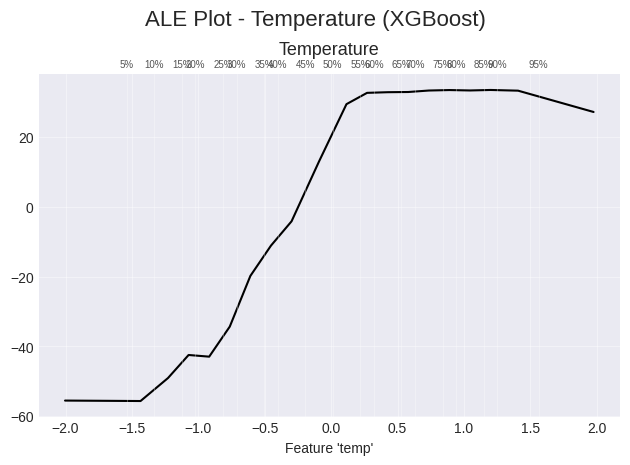


Génération ALE Plot - Humidity (XGBoost)...


<Figure size 1000x700 with 0 Axes>

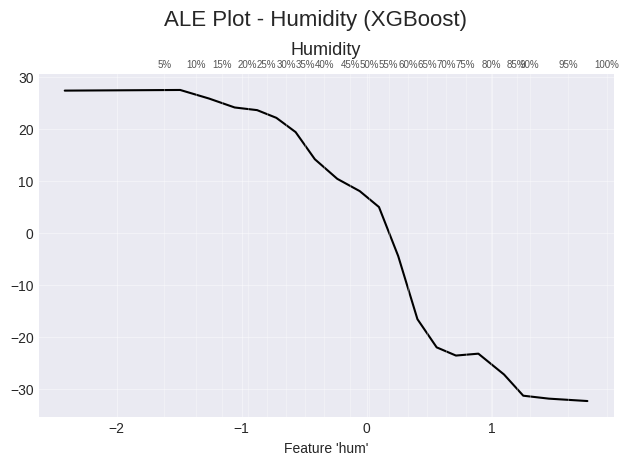


📊 ALE Plots pour XGBoost générés avec succès!


In [25]:
# ALE Plots pour XGBoost - VERSION CORRIGÉE
from alepython import ale_plot
import matplotlib.pyplot as plt

# ALE pour 'temp' (XGBoost)
print("Génération ALE Plot - Temperature (XGBoost)...")
fig = plt.figure(figsize=(10, 7))
ax = ale_plot(
    xgb_simple,
    X_train_nl,
    temp_col,  # Utiliser le nom de la colonne
    bins=20
)
ax.set_title('')
plt.suptitle('ALE Plot - Temperature (XGBoost)', fontsize=16, y=0.96)
plt.xlabel('Temperature', fontsize=13)
plt.ylabel('ALE (Accumulated Local Effects)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.subplots_adjust(top=0.90)
plt.tight_layout()
plt.show()

# ALE pour 'hum' (XGBoost)
print("\nGénération ALE Plot - Humidity (XGBoost)...")
fig = plt.figure(figsize=(10, 7))
ax = ale_plot(
    xgb_simple,
    X_train_nl,
    hum_col,  # Utiliser le nom de la colonne
    bins=20
)
ax.set_title('')
plt.suptitle('ALE Plot - Humidity (XGBoost)', fontsize=16, y=0.96)
plt.xlabel('Humidity', fontsize=13)
plt.ylabel('ALE (Accumulated Local Effects)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.subplots_adjust(top=0.90)
plt.tight_layout()
plt.show()

print("\n📊 ALE Plots pour XGBoost générés avec succès!")


In [26]:
# Entraîner MLPRegressor sur données transformées
mlp_simple = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    activation='relu',
    max_iter=1000,
    random_state=0
)
mlp_simple.fit(X_train_nl, y_train)

print(f"MLP R²: {mlp_simple.score(X_test_nl, y_test):.4f}")

MLP R²: 0.9112


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Génération ALE Plot - Temperature (MLP)...


<Figure size 1000x700 with 0 Axes>

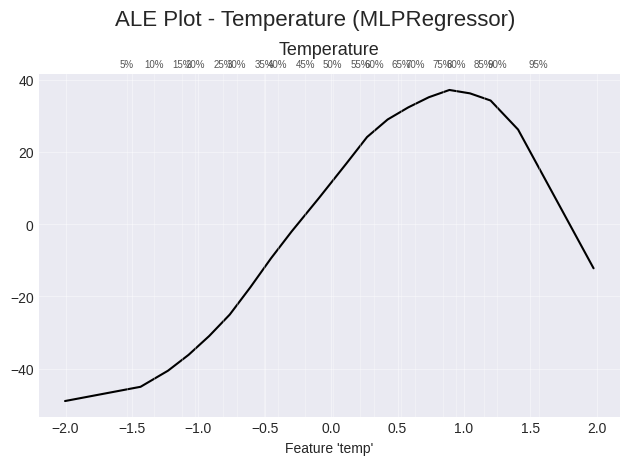


Génération ALE Plot - Humidity (MLP)...


<Figure size 1000x700 with 0 Axes>

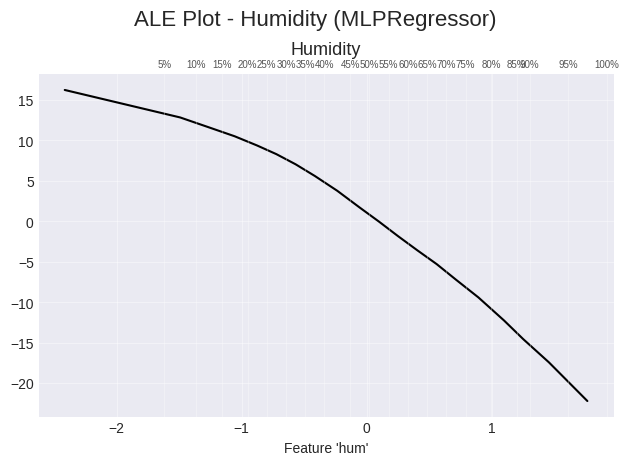


📊 ALE Plots pour MLP générés avec succès!


In [31]:
# ALE Plots pour MLP
print("\nGénération ALE Plot - Temperature (MLP)...")
fig = plt.figure(figsize=(10, 7))
ax = ale_plot(
    mlp_simple,
    X_train_nl,
    temp_col,
    bins=20
)
ax.set_title('')
plt.suptitle('ALE Plot - Temperature (MLPRegressor)', fontsize=16, y=0.96)
plt.xlabel('Temperature', fontsize=13)
plt.ylabel('ALE (Accumulated Local Effects)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.subplots_adjust(top=0.90)
plt.tight_layout()
plt.show()

print("\nGénération ALE Plot - Humidity (MLP)...")
fig = plt.figure(figsize=(10, 7))
ax = ale_plot(
    mlp_simple,
    X_train_nl,
    hum_col,
    bins=20
)
ax.set_title('')
plt.suptitle('ALE Plot - Humidity (MLPRegressor)', fontsize=16, y=0.96)
plt.xlabel('Humidity', fontsize=13)
plt.ylabel('ALE (Accumulated Local Effects)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.subplots_adjust(top=0.90)
plt.tight_layout()
plt.show()

print("\n📊 ALE Plots pour MLP générés avec succès!")


### Comparaison PDP vs ALE

#### Différences observées:

**1. Centrage:**
- **PDP**: Valeurs absolues (prix prédit réel)
- **ALE**: Centré sur 0 (déviation par rapport à la moyenne)

**2. Interprétation:**
- **PDP**: "Quel est le prix moyen quand temp=20°?"
- **ALE**: "Comment le prix change localement quand temp augmente?"

**3. Avantages ALE:**
- ✅ Plus rapide à calculer
- ✅ Respecte les corrélations entre features
- ✅ Évite les combinaisons irréalistes
- ✅ Plus précis pour modèles complexes

**4. Avantages PDP:**
- ✅ Plus facile à interpréter (valeurs absolues)
- ✅ Plus populaire et standard
- ✅ Implémentation native dans scikit-learn

### 🎯 Quand utiliser ALE vs PDP?

**Utilisez ALE si:**
- Vos features sont **fortement corrélées**
- Vous travaillez avec des **modèles complexes**
- Vous voulez des explications **plus précises**
- La **vitesse** est importante

**Utilisez PDP si:**
- Les features sont **peu corrélées**
- Vous voulez une **interprétation simple** (valeurs absolues)
- Vous présentez à des **non-experts**
- Vous utilisez **scikit-learn** (implémentation native)

---

## 📚 Ressources supplémentaires sur ALE

- **Paper original**: Apley, D. W., & Zhu, J. (2020). Visualizing the effects of predictor variables in black box supervised learning models. *Journal of the Royal Statistical Society*
- **ALEPython**: https://github.com/blent-ai/ALEPython
- **Interpretable ML Book**: https://christophm.github.io/interpretable-ml-book/ale.html

**Fin de la section ALE** ✅